In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import requests
import json
from matplotlib.pyplot import text

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


matplotlib.rcParams['font.size'] = 18
# matplotlib.rcParams['font.size'] = 16ho

import re
import time
import subprocess
import os
import signal


# Patch and benchmark control

In [2]:
backend_endpoint ="127.0.0.1:5000"

In [3]:


def reset_shares_cfs(backend=backend_endpoint):
    params = { 'script': 'setup_patch_clean_cfs.sh', "ema":"1000" }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text)    

def reset_shares_llf(backend=backend_endpoint, ema=1000):
    params = { 'script': 'setup_patch_clean_systemd.sh', "ema":ema }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text)       
    
def reset_shares_llf_static(backend=backend_endpoint):
    params = { 'script': 'setup_patch_clean_withrr_systemd.sh', "ema":1000 }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text)        
    
def rd_hashd_benchmark_start(backend=backend_endpoint, func_count=0,duration=100,llf=False, ftrace_enabled=False):
    params = { "funcs_count": func_count, "duration":duration, "llf": llf, "ema":1000  }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_start", params=params, headers={})
    print(r.text)  
    
def rd_hashd_benchmark_reports(backend=backend_endpoint):
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_reports", params={}, headers={})
    return r.text      

def rd_hashd_benchmark_killall(backend=backend_endpoint):
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_killall", params={}, headers={})
    return r.text     

def rd_hashd_benchmark_latencies_all_funcs(backend=backend_endpoint):
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_latencies_all_funcs", params={}, headers={})
    return r.text   
    
def rd_hashd_benchmark_end(backend=backend_endpoint, func_count=0,duration=100):
    params = { "funcs_count": func_count, "duration":duration }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_end", params=params, headers={})
    print(r.text)       

In [4]:
def rd_hashd_benchmark_end(backend=backend_endpoint, func_count=0,duration=100):
    params = { "funcs_count": func_count, "duration":duration }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_end", params=params, headers={})
    print(r.text)       

In [5]:
    
def rd_hashd_benchmark_hetro_start(backend=backend_endpoint, func_count=0,func_sm_count=0):
    params = { "funcs_count": func_count, "funcs_sm_count": func_sm_count, }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_hetro_start", params=params, headers={})
    print(r.text)  
    
def rd_hashd_benchmark_hetro_end(backend=backend_endpoint, func_count=0,func_sm_count=0):
    params = { "funcs_count": func_count, "funcs_sm_count": func_sm_count, }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_hetro_end", params=params, headers={})
    print(r.text)   

In [6]:
def run_host_script(backend=backend_endpoint,script='setup_patch_clean_systemd.sh'):
    params = { 'script': script, "ema":"1000" }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text)    

In [7]:
run_host_script(script="setup_patch_clean_cfs.sh")

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0 #1
ktime                                   : 210517.959600
sched_clk                               : 213187.522641
cpu_clk                                 : 211814.699495
jiffies                                 : 4294944783
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2399.924 MHz
  .nr_running                    : 0
  .nr_switches                   : 10912
  .nr_uninterruptible            : 30
-----
-----
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
0
0



In [135]:
reset_shares_cfs()
# reset_shares_llf_static()

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 257583384.612929
sched_clk                               : 257582491.307233
cpu_clk                                 : 257581966.978733
jiffies                                 : 4359288008
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

# Kernel metrics

In [8]:
# domain<N> <name> <cpumask> 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45

def schedstat_domains_snapshot():
    
    df = pd.DataFrame()
    
    backend=backend_endpoint
    r = requests.get(f"http://{backend}/schedstat_domains", params={}, headers={})
    schedstat_data = r.text    

    cpu = 0
    for line in schedstat_data.split('\n'):
        if len(line) > 0: 
#             print(line)
            cpu_entry = line.split(" ")
#             print([(a,b) for a,b in enumerate(cpu_entry)][:2])
#             print(cpu_entry[2:])
        
#             print([(a,b) for a,b in enumerate(cpu_entry)][2:])
#             print(cpu_entry[1],cpu_entry[4+1], cpu_entry[12+1], cpu_entry[20+1])
            entry = {
#                 "id": cpu_entry[1],
                "imbalances": int(cpu_entry[4+1]) + int(cpu_entry[12+1]) + int(cpu_entry[20+1]),
                
                "imbalance_idle":int(cpu_entry[4+1]),
                "pull_task_idle": int(cpu_entry[5+1]),
#                 "pull_task_idle_hotcache": int(cpu_entry[5+2]),
                
                "imbalance_busy": int(cpu_entry[12+1]),
                "pull_task_busy": int(cpu_entry[13+1]),
#                 "pull_task_busy_hotcache": int(cpu_entry[13+2]),
                
                "imbalance_newly_idle": int(cpu_entry[20+1]),
                "pull_task_newly_idle": int(cpu_entry[21+1]),
#                 "pull_task_newly_idle_hotcache": int(cpu_entry[21+1]),
                "active_load_balance": cpu_entry[27+1],
                "passive_load_balance": cpu_entry[36+1],
#                 "try_to_wake_up": cpu_entry[5],
#                 "try_to_wake_up local": cpu_entry[6],
#                 "tasks_running": cpu_entry[7],
#                 "tasks_waiting": cpu_entry[8],
#                 "timeslices": cpu_entry[9]
            }
            
            df[cpu] = cpu_entry[2:]
            cpu = cpu+1
                
#             for entry in range(1,9+1):
#                 value = cpu_entry[entry] # 3 of times schedule() was called
#     #             print("schedule()", value) 
#                 df[entry] = df[entry] + int(value)
            
    return df
    
a = schedstat_domains_snapshot()
time.sleep(10)
b = schedstat_domains_snapshot()

(b.astype(int) - a.astype(int)).sum(axis=1)
# b

0       38
1       38
2        0
3        0
4        0
5        0
6        0
7       38
8     1833
9     1833
10       0
11       0
12       0
13       0
14       0
15    1833
16     134
17     130
18       3
19       5
20       1
21       0
22       0
23     125
24       0
25       0
26       0
27       0
28       0
29       0
30       0
31       0
32       0
33      33
34       2
35       0
dtype: int64

In [9]:

def nr_switches_snapshot():
    df = pd.DataFrame()

    r = requests.get(f"http://{backend_endpoint}/nr_switches", params={}, headers={})
    nr_switches_data = r.text    
    
    data = []
    for line in nr_switches_data.split("\n"):
        if len(line) > 0: 
            data.append(int(line.split(":")[1]))
            
            
    df['nr_switches'] = data
            
            
    return df

In [10]:
# First field is a sched_yield() statistic:

# 0 of times sched_yield() was called

# Next three are schedule() statistics:

# 1 This field is a legacy array expiration count field used in the O(1) scheduler. We kept it for ABI compatibility, but it is always set to zero.

# 2 # of times schedule() was called

# 3 # of times schedule() left the processor idle

# Next two are try_to_wake_up() statistics:

# # 4 of times try_to_wake_up() was called

# # 5 of times try_to_wake_up() was called to wake up the local cpu

# Next three are statistics describing scheduling latency:

# 6 sum of all time spent running by tasks on this processor (in nanoseconds)

# 7 sum of all time spent waiting to run by tasks on this processor (in nanoseconds)

# 8 # of timeslices run on this cpu

def schedstat_snapshot():
    
    df = pd.DataFrame()
    
    r = requests.get(f"http://{backend_endpoint}/schedstat", params={}, headers={})
    schedstat_data = r.text    

    for line in schedstat_data.split('\n'):
        if len(line) > 0: 
            cpu_entry = line.split(" ")
#             print(len(cpu_entry), cpu_entry)
            entry = {
                "yield": cpu_entry[1],
                "schedule": cpu_entry[3],
                "idle": cpu_entry[4],
                "try_to_wake_up": cpu_entry[5],
                "try_to_wake_up local": cpu_entry[6],
                "tasks_running": cpu_entry[7],
                "tasks_waiting": cpu_entry[8],
                "timeslices": cpu_entry[9]
            }
            
            # df = df.append(entry,ignore_index=True)
            new_row_df = pd.DataFrame([entry])
            df = pd.concat([df, new_row_df], ignore_index=True)
            
            
                
#             for entry in range(1,9+1):
#                 value = cpu_entry[entry] # 3 of times schedule() was called
#     #             print("schedule()", value) 
#                 df[entry] = df[entry] + int(value)
            
    return df
    
a = schedstat_snapshot()
b = schedstat_snapshot()

display((b.astype(int) - a.astype(int)).sum())

nr_switches_start = nr_switches_snapshot()

# time.sleep(10)
nr_switches_end = nr_switches_snapshot()

display((nr_switches_end - nr_switches_start).sum())


yield                          0
schedule                      71
idle                          36
try_to_wake_up                31
try_to_wake_up local           9
tasks_running           55193834
tasks_waiting              86037
timeslices                    35
dtype: int64

nr_switches    121
dtype: int64

# Benchmark data processing

In [11]:
def process_snapshot(json_files):
    
#     print(json_files)
    
    concurrency_per_func = [json.loads(file)['concurrency'] for file in json_files]
    rps_per_func = [json.loads(file)['rps'] for file in json_files]
    
    nr_workers_per_func = [json.loads(file)['nr_workers'] for file in json_files]
    nr_idle_workers_per_func = [json.loads(file)['nr_idle_workers'] for file in json_files]
    nr_in_flight_per_func = [json.loads(file)['nr_in_flight'] for file in json_files]
    
    nr_done_per_func = [json.loads(file)['nr_done'] for file in json_files]
    lat_p95_per_func = [json.loads(file)['lat']['p95'] for file in json_files]
    lat_p50_per_func = [json.loads(file)['lat']['p50'] for file in json_files]


    print('concurrency_per_func', concurrency_per_func, sum(concurrency_per_func))
    print('rps_per_func', rps_per_func, sum(rps_per_func))
    
    print('nr_workers_per_func', nr_workers_per_func, sum(nr_workers_per_func))
    print('nr_idle_workers_per_func', nr_idle_workers_per_func,sum(nr_idle_workers_per_func))
    print('nr_in_flight_per_func', nr_in_flight_per_func, sum(nr_in_flight_per_func))    
    
    print('nr_done_per_func', nr_done_per_func, sum(nr_done_per_func))
    
    print('lat_p95_per_func', lat_p95_per_func, max(lat_p95_per_func))        
    print('lat_p50_per_func', lat_p50_per_func, max(lat_p50_per_func))     
    
    return [sum(concurrency_per_func),sum(rps_per_func),
            sum(nr_done_per_func),
            max(lat_p95_per_func),
            max(lat_p50_per_func)]

def hashd_report_snapshot():
    
    try:
        single = rd_hashd_benchmark_reports()
        json.loads(single)
        
        json_files = [single]
        print("single json file")
    except:
  
        raw_data = [row for row in rd_hashd_benchmark_reports().split("==> /local/scratch/rd-hashd/")[1:]]

        json_filenames = [row.split(" <==")[0] for row in raw_data ]
        json_files = [row.split(" <==")[1] for row in raw_data ]

        print("fetched the following JSON files", len(json_filenames),json_filenames)
    # print("with the following keys",  json.loads(json_files[0]).keys())
    
    process_snapshot(json_files)
    
    return json_files



In [12]:
hashd_report_snapshot()

fetched the following JSON files 0 []
concurrency_per_func [] 0
rps_per_func [] 0
nr_workers_per_func [] 0
nr_idle_workers_per_func [] 0
nr_in_flight_per_func [] 0
nr_done_per_func [] 0


ValueError: max() arg is an empty sequence

In [13]:
# latencies_raw = rd_hashd_benchmark_latencies_all_funcs()

def process_latencies(latencies_raw):
    
    logs_per_func = [s for s in latencies_raw.split("\n") if re.match('logs-\d+|logs-sm-\d+',s)]
    latencies_per_func_raw = re.split(r'logs-\d+|logs-sm-\d+', latencies_raw)[1:]

    # the number of log file names should be equal to the actual number of files
    assert (len(logs_per_func) == len(latencies_per_func_raw))
    
    if (len(logs_per_func) == 0):
        logs_per_func = [s for s in [latencies_raw.split("\n")]]
        latencies_per_func_raw = [latencies_raw]  
    

    per_func_latencies_raw = [group.split("\n")[1:-1] for group in latencies_per_func_raw]
    
    
    def extract_latencies(group):
        return [float(r.strip("ms")) for r in group]

    data = [extract_latencies(group) for group in per_func_latencies_raw]
        
    if (len(logs_per_func) == 1):
        df = pd.DataFrame(data[0],columns=["logs-0"])
        df.hist(cumulative=True, density=1, bins=1000,histtype='step',figsize=(3,2))
        plt.show()
        
    else:

        df = pd.DataFrame(data).transpose()

        df.columns = logs_per_func
#         axs = df.hist(cumulative=True, density=1, bins=1000,histtype='step',figsize=(15,10))

#         plt.tight_layout()
#         for row in axs:
#             for ax in row:
#                 ax.set_xlim(0,1500)

#         plt.show()
#         pd.Series(df.to_numpy().flatten()).hist(cumulative=True, density=0, bins=1000,histtype='step',figsize=(4,2))
#         plt.show()
    return df

# process_latencies(latencies_raw)

# Preparing files

In [15]:


def rd_hashd_benchmark_args_workload(backend=backend_endpoint,workload='none',functions=400):
    params = { 'workload': workload, "functions":functions }
    r = requests.get(f"http://{backend}/rd_hashd_benchmark_args_workload", params=params, headers={})
    print(r.text.split('\n')[-10:])   
    
rd_hashd_benchmark_args_workload(workload='none',functions=360)    

['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-994",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-995",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-996",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-997",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-998",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-999",', '']


# Parameter space

In [16]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json | grep '\/\/'

# //
# // rd-hashd runtime parameters
# //
# // All parameters can be updated while running and will be applied immediately.
# //
# // rd-hashd keeps calculating SHA1s of different parts of testfiles using
# // concurrent worker threads. The testfile indices and hash sizes are
# // determined using truncated normal distributions which gradually transforms
# // to uniform distributions as their standard deviations increase.
# //
# // All durations are in seconds and memory bytes. A _frac field should be <=
# // 1.0 and specifies a sub-proportion of some other value. A _ratio field is
# // similar but may be greater than 1.0.
# //
# // The concurrency level is modulated using two PID controllers to target the
# // specified latency and RPS so that neither is exceeded. The total number
# // of concurrent threads is limited by `concurrency_max`.
# //
# // The total size of testfiles is set up during startup and can't be changed
# // online. However, the portion which is actively used by rd

## Parameter space - independent values

In [17]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json  | grep -v '\/\/\|lat_target\|sleep\|concurrency'

{
  "control_period": 1.0,
  "rps_target": 65536,
  "rps_max": 1000,
  "mem_frac": 0.001,
  "chunk_pages": 25,
  "file_frac": 0.25,
  "file_size_mean": 377487,
  "file_size_stdev_ratio": 0.45,
  "file_addr_stdev_ratio": 0.215,
  "file_addr_rps_base_frac": 0.5,
  "file_write_frac": 0.0,
  "anon_size_ratio": 2.3,
  "anon_size_stdev_ratio": 0.45,
  "anon_addr_stdev_ratio": 0.235,
  "anon_addr_rps_base_frac": 0.5,
  "anon_write_frac": 0.3,
  "cpu_ratio": 0.93,
  "log_bps": 1100794,
  "fake_cpu_load": false,
  "acc_dist_slots": 0,
  "lat_pid": {
    "kp": 0.1,
    "ki": 0.01,
    "kd": 0.01
  },
  "rps_pid": {
    "kp": 0.25,
    "ki": 0.01,
    "kd": 0.01
  }
}


## Parameter space - tuned values

In [18]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json  | grep 'lat_target\|sleep\|concurrency'

# // The concurrency level is modulated using two PID controllers to target the
# // of concurrent threads is limited by `concurrency_max`.
# // Worker threads will sleep according to the sleep duration distribution and
# //  concurrency_max: Maximum number of worker threads
# //  lat_target_pct: Latency target percentile
# //  lat_target: Latency target
# //  sleep_mean: Worker sleep duration average
# //  sleep_stdev_ratio: Standard deviation of sleep duration distribution
  "concurrency_max": 65536,
  "lat_target_pct": 0.5,
  "lat_target": 0.1,
  "sleep_mean": 0.02,
  "sleep_stdev_ratio": 0.33,


# Experiment code

In [19]:

def enable_schedstats(backend=backend_endpoint,enabled=1):
    params = { "enabled":enabled }
    r = requests.get(f"http://{backend}/enable_schedstats", params=params, headers={})
    print(r.text) 
    
enable_schedstats()    

kernel.sched_schedstats = 1



In [20]:
def rd_hashd_experiment(func_count = 20,
                        llf=False, 
                        llf_static=False,
                        script ='setup_patch_clean_cfs.sh',
                        ema=1000,
                        duration=150,
                        workload='none',
                        schedstats_enabled=False, 
                        ftrace_enabled=False):

    #machine reset
    reset_shares_cfs()
    a = int(func_count)
    print(a, "functions")
    
    rd_hashd_benchmark_args_workload(workload=workload,functions=360)  
    
    #benchmark kickoff
    rd_hashd_benchmark_start(func_count=(a-1),llf=llf, ftrace_enabled=ftrace_enabled)
#     if (llf): reset_shares_llf(ema=ema)
#     if (llf_static): reset_shares_llf_static()
    # time.sleep(10)    
    print(f"running script {script}")
    run_host_script(script=script)
        
    #instrumentation begins here
    ts_start = time.time()    
    if ftrace_enabled:
#         function_profile_enabled(enabled=0)    
        function_profile_enabled(enabled=1)
        cat_trace_stat()
    if schedstats_enabled:
        enable_schedstats(enabled=1)
    schedstat_start = schedstat_snapshot()
    schedstat_domains_start = schedstat_domains_snapshot()
    nr_switches_start = nr_switches_snapshot()

    #experiment timer        
    interval=10
    snapshots = []
    for i in range(0,duration,interval):
        print("tick",i)
#         snapshots.append(hashd_report_snapshot())
        time.sleep(interval)
    snapshots_hetro = snapshots

    #instrumentation end    
    ts_end = time.time()    
    schedstat_end = schedstat_snapshot()
    schedstat_domains_end = schedstat_domains_snapshot()
    nr_switches_end = nr_switches_snapshot()
    if ftrace_enabled:
        ftrace_data_raw = cat_trace_stat()
    
    #benchmark killed
    rd_hashd_benchmark_killall()
    rd_hashd_benchmark_end(func_count=(a-1))
    
    #machine reset
    reset_shares_cfs()    
    
    #display results
    print('duration', ts_end-ts_start, 'seconds')
    schedstat_hetro = (schedstat_end.astype(int) - schedstat_start.astype(int)).sum()
    # scheddomain_hetro = (schedstat_domains_end.astype(int) - schedstat_domains_start.astype(int)).sum(axis=1)
    scheddomain_hetro = None
    display((nr_switches_end - nr_switches_start).sum())

    display(schedstat_hetro)
    # display(scheddomain_hetro) 
    if ftrace_enabled:
        ftrace_data = process_ftrace_data(ftrace_data_raw)
    else: ftrace_data = None

    latencies_raw = rd_hashd_benchmark_latencies_all_funcs()
    df = process_latencies(latencies_raw)

    return (df,
        schedstat_hetro,
        scheddomain_hetro, 
        ftrace_data,
        ts_end-ts_start)



# Results (no special kernel metrics)

In [26]:
density_range = [x for x in range(12, 12*20, 12*4)]
density_range = [12]
# density_range = [204]
results_notraceclean_cfs = {}

results_notraceclean_llf = {}


In [21]:
density_range = [12, 36, 132, 228]


In [63]:

print(density_range)

for x in density_range: 
    results_notraceclean_cfs[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


print(density_range)

for x in density_range: 
    results_notraceclean_llf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)                                                   

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

12 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/n

nr_switches    568525
dtype: int64

yield                          343136
schedule                       718166
idle                            10872
try_to_wake_up                 168172
try_to_wake_up local           120022
tasks_running           1154749805969
tasks_waiting           2517396234740
timeslices                     557578
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

36 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-994",', '

nr_switches    667060
dtype: int64

...

yield                           331331
schedule                        910816
idle                             28013
try_to_wake_up                  241290
try_to_wake_up local            168472
tasks_running            1180904663022
tasks_waiting           32058761805014
timeslices                      616493
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0
kernel.sched_cpu_has_higher_load_task = 0
-----
kernel.sched_tg_load_avg_ema = 0
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/cpu/*/cpu.shares
/sys/fs/cgroup/cpu/*/*/cpu.shares
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/*/*/cpu.latency_awareness
0
0
0
-----

228 functions
['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-994",', 

nr_switches    420300
dtype: int64

yield                           187882
schedule                        665963
idle                              1269
try_to_wake_up                  159985
try_to_wake_up local            139139
tasks_running            1196855834845
tasks_waiting           54416780738668
timeslices                      418927
dtype: int64

yield                           403054
schedule                       1023153
idle                                 0
try_to_wake_up                  322468
try_to_wake_up local            310216
tasks_running            1203532479113
tasks_waiting           40984016675227
timeslices                      806323
dtype: int64

In [72]:
results_notraceclean_llf.keys()

dict_keys([12, 36, 132, 204, 228])

In [67]:
sort_dict_by_keys = lambda d: {key: d[key] for key in sorted(d)}


In [69]:
results_notraceclean_llf = sort_dict_by_keys(results_notraceclean_llf)
results_notraceclean_cfs = sort_dict_by_keys(results_notraceclean_cfs)

In [29]:

def visualise_latency_cdf(results_cfs, results_llf, fig, ax,workload,func_count):
    dfs = [df for df, _, _, _, _ in results_cfs.values()]
    dfs_llf = [df for df, _, _, _, _ in results_llf.values()]


    dfs = [pd.Series(df.to_numpy().flatten()) for df in dfs]
    dfs_llf = [pd.Series(df.to_numpy().flatten()) for df in dfs_llf]


    dfb = dfs[0]

    for index, count in enumerate(list(results_cfs.keys())):

#         print(index, count)
        
        if (count == func_count):

            quantile = 0.95

            dfb[dfb<dfb.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                                 histtype='step',
                                                  label=f'{12}-funcs-CFS',ax=ax)

            df = dfs[index]
            df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                              histtype='step',
                                              label=f'{count}-funcs-CFS',ax=ax)

            df = dfs_llf[index]
            df[df<df.quantile(quantile)].hist(cumulative=True, density=1, bins=1000,
                                              histtype='step',
                                              label=f'{count}-funcs-CFS-LLF',ax=ax)     


            ax.set_title(workload,)
            ax.set_xlabel("milliseconds")

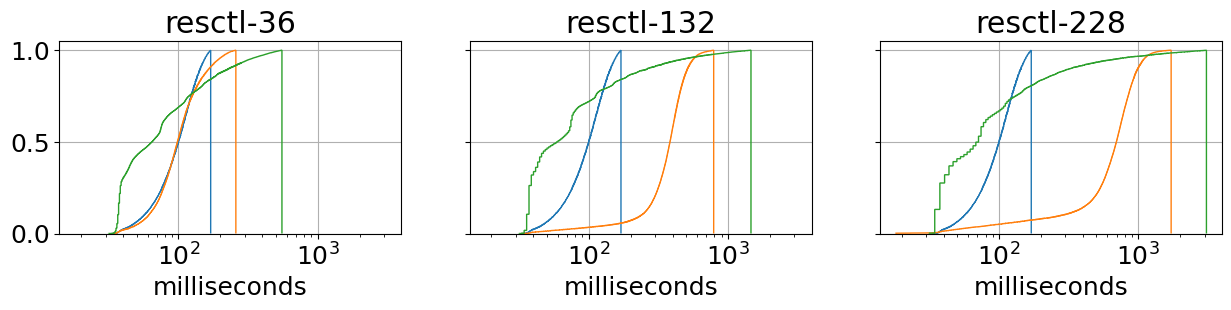

In [73]:


fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[0],'resctl-36',36)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[1],'resctl-132',132)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)



In [121]:
!diff --color ../scripts/setup_patch_clean_cfs.sh ../scripts/setup_patch_clean_tuned.sh

10,13c10,13
< echo '24000000' | sudo tee -a /sys/kernel/debug/sched/latency_ns
< echo '3000000' | sudo tee -a /sys/kernel/debug/sched/min_granularity_ns
< echo '4000000' | sudo tee -a /sys/kernel/debug/sched/wakeup_granularity_ns
< echo '750000' | sudo tee -a /sys/kernel/debug/sched/idle_min_granularity_ns
---
> echo '240000000' | sudo tee -a /sys/kernel/debug/sched/latency_ns
> echo '30000000' | sudo tee -a /sys/kernel/debug/sched/min_granularity_ns
> echo '40000000' | sudo tee -a /sys/kernel/debug/sched/wakeup_granularity_ns
> echo '7500000' | sudo tee -a /sys/kernel/debug/sched/idle_min_granularity_ns


In [94]:
results_notraceclean_cfstuned = {}

In [95]:
for x in density_range: 
    results_notraceclean_cfstuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 73084753.146115
sched_clk                               : 73085858.554346
cpu_clk                                 : 73085334.225824
jiffies                                 : 4313163351
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awarene

nr_switches    390840
dtype: int64

yield                          222032
schedule                       493598
idle                            26517
try_to_wake_up                 166877
try_to_wake_up local           104949
tasks_running           1158991178102
tasks_waiting           5250982949611
timeslices                     364348
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 73200931.286786
sched_clk                               : 73202035.441806
cpu_clk                                 : 73201511.113304
jiffies                                 : 4313192395
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awarene

nr_switches    556045
dtype: int64

...

nr_switches    703790
dtype: int64

yield                           396676
schedule                        846571
idle                             38638
try_to_wake_up                  277589
try_to_wake_up local            213351
tasks_running            1183634967401
tasks_waiting           24343396149991
timeslices                      668304
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 73447815.212151
sched_clk                               : 73448916.703280
cpu_clk                                 : 73448392.374763
jiffies                                 : 4313254116
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awarene

nr_switches    600204
dtype: int64

yield                           359895
schedule                        727076
idle                              4378
try_to_wake_up                  232226
try_to_wake_up local            205089
tasks_running            1197145378617
tasks_waiting           43724882502749
timeslices                      595656
dtype: int64

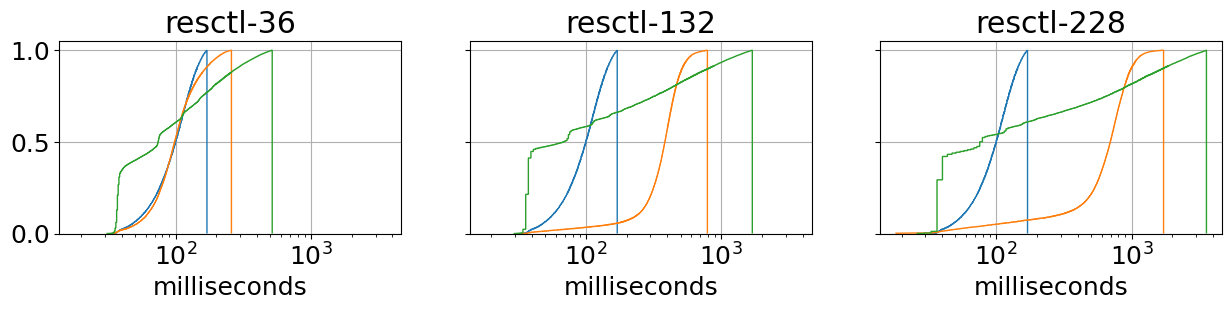

In [96]:

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_cfstuned,fig,ax[0],'resctl-36',36)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_cfstuned,fig,ax[1],'resctl-132',132)
visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_cfstuned,fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)

# Multithreaded workload

In [97]:
results_notracemultithreaded_cfs = {}
results_notracemultithreaded_cfstuned = {}

In [103]:
results_notracemultithreaded_llf = {}


In [132]:
results_notracemultithreaded_rr = {}


In [111]:
print(density_range)


[12, 36, 132, 228]


In [129]:
density_range = [12, 36, 132, 228]


In [112]:

print(density_range)

for x in density_range: 
    results_notracemultithreaded_cfs[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


                                            

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 164714594.481049
sched_clk                               : 164714707.166239
cpu_clk                                 : 164714182.837707
jiffies                                 : 4336070811
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_

nr_switches    409034
dtype: int64

yield                          157377
schedule                       522756
idle                            19429
try_to_wake_up                 155803
try_to_wake_up local            95363
tasks_running           1156034486731
tasks_waiting           1564857853164
timeslices                     389681
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 164829437.255438
sched_clk                               : 164829548.682654
cpu_clk                                 : 164829024.354161
jiffies                                 : 4336099522
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    496486
dtype: int64

...

nr_switches    713264
dtype: int64

yield                           222126
schedule                        890235
idle                             33073
try_to_wake_up                  275705
try_to_wake_up local            206294
tasks_running            1187234200740
tasks_waiting           25739514982687
timeslices                      683237
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 165073771.155488
sched_clk                               : 165073879.911502
cpu_clk                                 : 165073355.583012
jiffies                                 : 4336160605
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    755790
dtype: int64

yield                           248202
schedule                        937874
idle                                 0
try_to_wake_up                  296771
try_to_wake_up local            265772
tasks_running            1202582376859
tasks_waiting           53932997823586
timeslices                      756718
dtype: int64

In [158]:

print(density_range)

for x in density_range: 
    results_notracemultithreaded_rr[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',script='setup_patch_clean_rr.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 260147532.205909
sched_clk                               : 260146611.339528
cpu_clk                                 : 260146087.011027
jiffies                                 : 4359929045
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_

nr_switches    308242
dtype: int64

yield                          145565
schedule                       416526
idle                            17361
try_to_wake_up                 159331
try_to_wake_up local            61808
tasks_running           1186256594069
tasks_waiting           3071645437696
timeslices                     291937
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 260285877.959067
sched_clk                               : 260284955.605657
cpu_clk                                 : 260284431.277137
jiffies                                 : 4359963632
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    444606
dtype: int64

...

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 260414035.352179
sched_clk                               : 260413111.620164
cpu_clk                                 : 260412587.291652
jiffies                                 : 4359995671
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    634090
dtype: int64

yield                           227792
schedule                        809840
idle                                 1
try_to_wake_up                  221722
try_to_wake_up local            192694
tasks_running            1202926143106
tasks_waiting           20465587538390
timeslices                      634421
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 260553499.148219
sched_clk                               : 260552573.915082
cpu_clk                                 : 260552049.586570
jiffies                                 : 4360030537
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar


KeyboardInterrupt



In [160]:

print(density_range)

for x in density_range: 
    results_notracemultithreaded_rr[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',script='setup_patch_clean_rr.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 260730776.167263
sched_clk                               : 260729849.024986
cpu_clk                                 : 260729324.696485
jiffies                                 : 4360074856
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_

nr_switches    351008
dtype: int64

yield                          140987
schedule                       453506
idle                            34960
try_to_wake_up                 184797
try_to_wake_up local            57465
tasks_running           1151651497025
tasks_waiting           2838069830849
timeslices                     314096
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 260850612.431296
sched_clk                               : 260849683.997961
cpu_clk                                 : 260849159.669468
jiffies                                 : 4360104815
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    324217
dtype: int64

...

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 260973745.874602
sched_clk                               : 260972816.114384
cpu_clk                                 : 260972291.785861
jiffies                                 : 4360135599
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    250722
dtype: int64

yield                           124023
schedule                        278408
idle                             16557
try_to_wake_up                   97865
try_to_wake_up local             47562
tasks_running            1181953504942
tasks_waiting           13223841332823
timeslices                      234478
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 261144942.800979
sched_clk                               : 261144011.195553
cpu_clk                                 : 261143486.867058
jiffies                                 : 4360178398
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar


KeyboardInterrupt



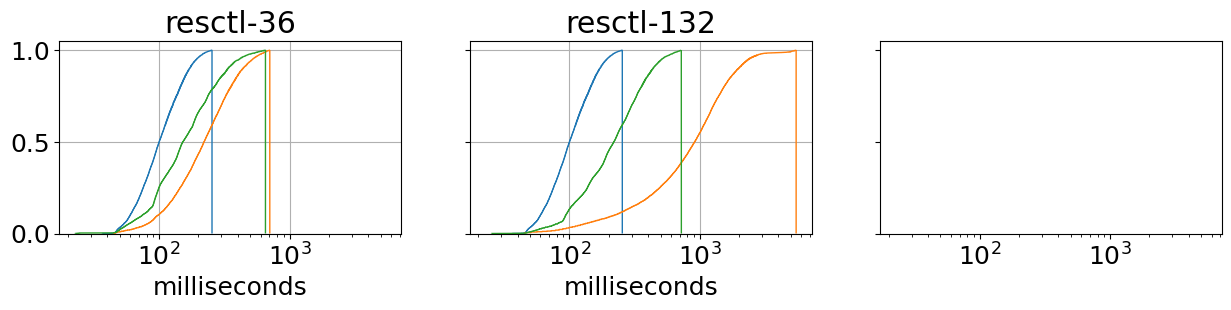

In [161]:

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_rr,fig,ax[0],'resctl-36',36)
visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_rr,fig,ax[1],'resctl-132',132)
# visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_rr,fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)

In [130]:

print(density_range)

for x in density_range: 
    results_notracemultithreaded_llf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none',script='setup_patch_clean_systemd.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


                                            

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 254525659.083394
sched_clk                               : 254524798.836023
cpu_clk                                 : 254524274.507505
jiffies                                 : 4358523577
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_

nr_switches    388794
dtype: int64

yield                          153758
schedule                       519790
idle                             9649
try_to_wake_up                 143342
try_to_wake_up local            98566
tasks_running           1157326140401
tasks_waiting           1588267134152
timeslices                     379053
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 254639970.122866
sched_clk                               : 254639108.635314
cpu_clk                                 : 254638584.306799
jiffies                                 : 4358552155
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    486773
dtype: int64

...

nr_switches    514225
dtype: int64

yield                           154835
schedule                        686530
idle                             19462
try_to_wake_up                  180868
try_to_wake_up local            123472
tasks_running            1186772661214
tasks_waiting           52044820169039
timeslices                      497413
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 254881906.968162
sched_clk                               : 254881042.856154
cpu_clk                                 : 254880518.527641
jiffies                                 : 4358612639
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    463589
dtype: int64

yield                            151619
schedule                         626737
idle                                  0
try_to_wake_up                   144763
try_to_wake_up local             125325
tasks_running             1202733648712
tasks_waiting           144212298843690
timeslices                       464519
dtype: int64

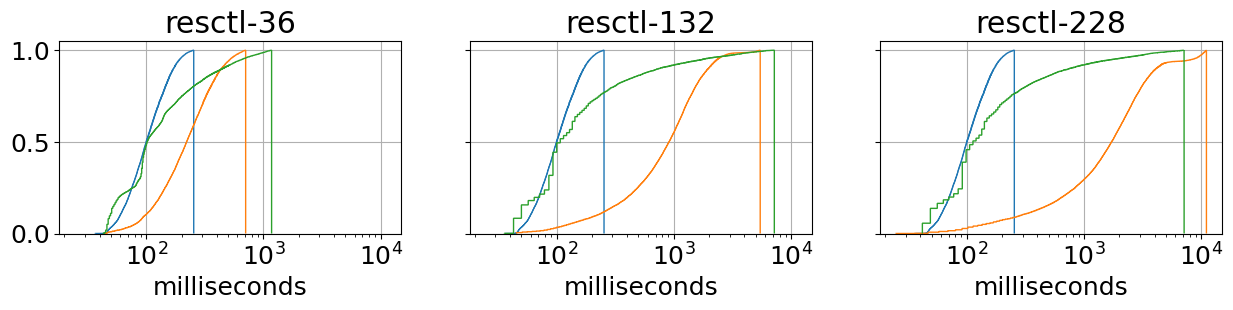

In [131]:

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_llf,fig,ax[0],'resctl-36',36)
visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_llf,fig,ax[1],'resctl-132',132)
visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_llf,fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)

In [162]:
!diff --color ../scripts/setup_patch_clean_cfs.sh ../scripts/setup_patch_clean_tuned.sh

6,7c6,7
< echo '24000000' | sudo tee -a /sys/kernel/debug/sched/latency_ns
< echo '3000000' | sudo tee -a /sys/kernel/debug/sched/min_granularity_ns
---
> echo '1000000000' | sudo tee -a /sys/kernel/debug/sched/latency_ns
> echo '100000000' | sudo tee -a /sys/kernel/debug/sched/min_granularity_ns


In [163]:

print(density_range)

for x in density_range: 
    results_notracemultithreaded_cfstuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 261730654.903216
sched_clk                               : 261729716.982760
cpu_clk                                 : 261729192.654235
jiffies                                 : 4360324826
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_

nr_switches    382337
dtype: int64

yield                          158993
schedule                       473975
idle                            24281
try_to_wake_up                 166356
try_to_wake_up local            97909
tasks_running           1162792601132
tasks_waiting           1428959560180
timeslices                     358180
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 261845590.074983
sched_clk                               : 261844650.915102
cpu_clk                                 : 261844126.586584
jiffies                                 : 4360353560
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    418174
dtype: int64

...

nr_switches    497150
dtype: int64

yield                           189708
schedule                        596864
idle                             27152
try_to_wake_up                  225927
try_to_wake_up local            160174
tasks_running            1186675117899
tasks_waiting           23660510585134
timeslices                      473983
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #1
ktime                                   : 262090368.476333
sched_clk                               : 262089426.676715
cpu_clk                                 : 262088902.348208
jiffies                                 : 4360414754
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    396168
dtype: int64

yield                           176613
schedule                        468735
idle                                 0
try_to_wake_up                  155605
try_to_wake_up local            139910
tasks_running            1202481998870
tasks_waiting           31020084524358
timeslices                      396140
dtype: int64

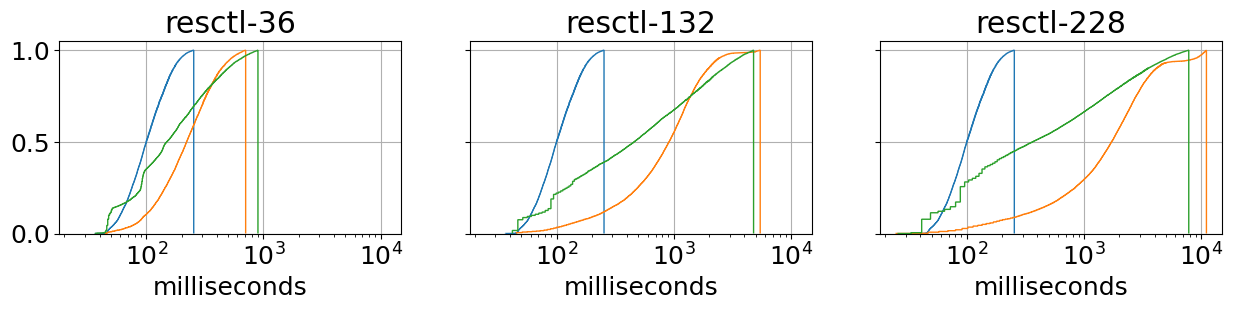

In [164]:

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_cfstuned,fig,ax[0],'resctl-36',36)
visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_cfstuned,fig,ax[1],'resctl-132',132)
visualise_latency_cdf(results_notracemultithreaded_cfs, results_notracemultithreaded_cfstuned,fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)

In [22]:
variables = [
    ('results_notracemultithreaded_cfs',results_notracemultithreaded_cfs),
    ('results_notracemultithreaded_llf',results_notracemultithreaded_llf),
    ('results_notracemultithreaded_rr',results_notracemultithreaded_rr),
    ('results_notracemultithreaded_cfstuned',results_notracemultithreaded_cfstuned)
]

NameError: name 'results_notracemultithreaded_cfs' is not defined

In [26]:
import pickle


In [171]:
for key,val in variables:
    print(key)
    file_dump = open(f'pickled/{key}', 'wb')
    pickle.dump(val, file_dump)

results_notracemultithreaded_cfs
results_notracemultithreaded_llf
results_notracemultithreaded_rr
results_notracemultithreaded_cfstuned


In [45]:
!ls pickled -l

total 4604
-rw-r--r-- 1 root root  479405 Jul 26 14:42 results_notracemultithreaded_cfs
-rw-r--r-- 1 root root  789005 Jul 26 14:45 results_notracemultithreaded_cfstuned
-rw-r--r-- 1 root root  621773 Jul 26 15:50 results_notracemultithreaded_eevdf
-rw-r--r-- 1 root root  621773 Jul 26 15:50 results_notracemultithreaded_eevdf_tuned
-rw-r--r-- 1 root root 1433361 Jul 26 14:42 results_notracemultithreaded_llf
-rw-r--r-- 1 root root  761836 Jul 26 14:42 results_notracemultithreaded_rr


In [47]:
pickled = !ls pickled
pickled_data = {}

for key in pickled:
    print(key)
    file_dump = open(f'pickled/{key}', 'rb')
    pickled_data[key] = pickle.load(file_dump)
    print(pickled_data[key].keys())

results_notracemultithreaded_cfs
dict_keys([12, 36, 132, 228])
results_notracemultithreaded_cfstuned
dict_keys([12, 36, 132, 228])
results_notracemultithreaded_eevdf
dict_keys([12, 36, 132, 228])
results_notracemultithreaded_eevdf_tuned
dict_keys([12, 36, 132, 228])
results_notracemultithreaded_llf
dict_keys([12, 36, 132, 228])
results_notracemultithreaded_rr
dict_keys([12, 36, 132, 228])


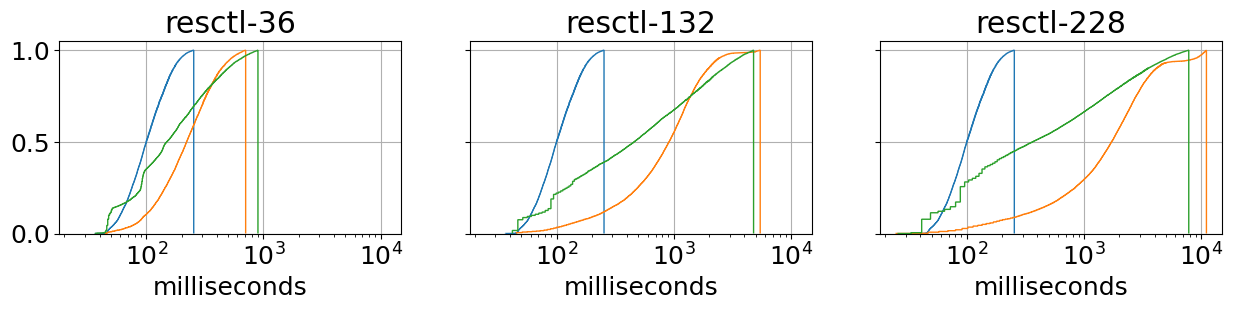

In [30]:

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], pickled_data['results_notracemultithreaded_cfstuned'],fig,ax[0],'resctl-36',36)
visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], pickled_data['results_notracemultithreaded_cfstuned'],fig,ax[1],'resctl-132',132)
visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], pickled_data['results_notracemultithreaded_cfstuned'],fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)

# EEVDF

In [31]:
results_notracemultithreaded_eevdf = {}

In [39]:

print(density_range)

for x in density_range: 
    results_notracemultithreaded_eevdf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none',script='setup_patch_clean_eevdf.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)
                                            

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0 #1
ktime                                   : 2337452.886126
sched_clk                               : 2340103.865233
cpu_clk                                 : 2338731.042103
jiffies                                 : 4295476517
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2399.924 MHz
  .nr_running                    : 0
  .nr_switches                   : 635404
  .nr_uninterruptible            : 1736
-----
-----
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
0
0

12 functions
['//"t

nr_switches    451345
dtype: int64

yield                          163039
schedule                       640404
idle                            25767
try_to_wake_up                 143858
try_to_wake_up local            91680
tasks_running           1166013072115
tasks_waiting           1783057117290
timeslices                     425527
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0 #1
ktime                                   : 2452962.348457
sched_clk                               : 2455611.809350
cpu_clk                                 : 2454238.986225
jiffies                                 : 4295505394
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2399.924 MHz
  .nr_running                    : 0
  .nr_switches                   : 677080
  .nr_uninterruptible            : 1729
-----
-----
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
0
0

36 functions
['//"trace_path": "/local/s

nr_switches    521365
dtype: int64

...

nr_switches    539124
dtype: int64

yield                           208213
schedule                        753324
idle                                 3
try_to_wake_up                  173636
try_to_wake_up local            147311
tasks_running            1203144467431
tasks_waiting           27604290210004
timeslices                      539208
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0 #1
ktime                                   : 2705748.586401
sched_clk                               : 2708395.282244
cpu_clk                                 : 2707022.459109
jiffies                                 : 4295568591
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2399.924 MHz
  .nr_running                    : 0
  .nr_switches                   : 820789
  .nr_uninterruptible            : 2305
-----
-----
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
0
0

228 functions
['//"trace_path": "/local/

nr_switches    484085
dtype: int64

yield                           175182
schedule                        701301
idle                                 1
try_to_wake_up                  164010
try_to_wake_up local            143146
tasks_running            1203003229531
tasks_waiting           43638721064717
timeslices                      483986
dtype: int64

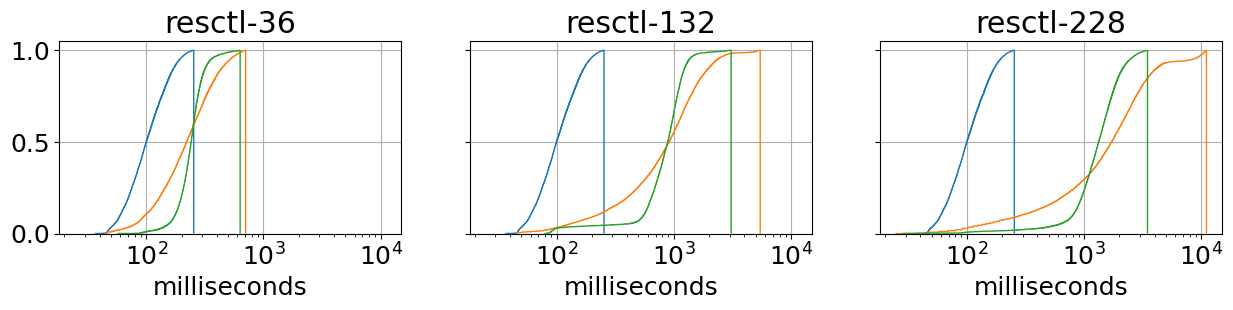

In [41]:

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], results_notracemultithreaded_eevdf,fig,ax[0],'resctl-36',36)
visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], results_notracemultithreaded_eevdf,fig,ax[1],'resctl-132',132)
visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], results_notracemultithreaded_eevdf,fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)

In [35]:

print(density_range)

for x in density_range: 
    results_notracemultithreaded_eevdf_tuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_eevdf_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)
                                            

[12, 36, 132, 228]
vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0 #1
ktime                                   : 1638642.104604
sched_clk                               : 1641299.513773
cpu_clk                                 : 1639926.690640
jiffies                                 : 4295301814
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 3.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2399.924 MHz
  .nr_running                    : 0
  .nr_switches                   : 354149
  .nr_uninterruptible            : 996
-----
-----
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
0
0

12 functions
['//"trac

nr_switches    305741
dtype: int64

yield                          160526
schedule                       446953
idle                             7862
try_to_wake_up                 126570
try_to_wake_up local            96637
tasks_running           1167962234732
tasks_waiting           1742710517567
timeslices                     297972
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0 #1
ktime                                   : 1753801.287847
sched_clk                               : 1756458.061054
cpu_clk                                 : 1755085.237914
jiffies                                 : 4295330604
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2399.924 MHz
  .nr_running                    : 0
  .nr_switches                   : 390567
  .nr_uninterruptible            : 999
-----
-----
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
0
0

36 functions
['//"trace_path": "/local/

nr_switches    345481
dtype: int64

...

nr_switches    424079
dtype: int64

yield                           199531
schedule                        584437
idle                                 0
try_to_wake_up                  156497
try_to_wake_up local            130492
tasks_running            1202871234716
tasks_waiting           27905933540164
timeslices                      424151
dtype: int64

vm.drop_caches = 3
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 6.12.0 #1
ktime                                   : 2005846.539636
sched_clk                               : 2008502.112712
cpu_clk                                 : 2007129.289567
jiffies                                 : 4295393615
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_base_slice                 : 100.000000
  .sysctl_sched_features                   : 32695263
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

cpu#0, 2399.924 MHz
  .nr_running                    : 0
  .nr_switches                   : 516200
  .nr_uninterruptible            : 1444
-----
-----
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/cpu/*/cpu.latency_awareness
/sys/fs/cgroup/cpu/*/*/cpu.latency_awareness
0
0

228 functions
['//"trace_path": "/loca

nr_switches    358365
dtype: int64

yield                           172733
schedule                        498674
idle                                 0
try_to_wake_up                  149010
try_to_wake_up local            130029
tasks_running            1203278855631
tasks_waiting           41840870956474
timeslices                      358347
dtype: int64

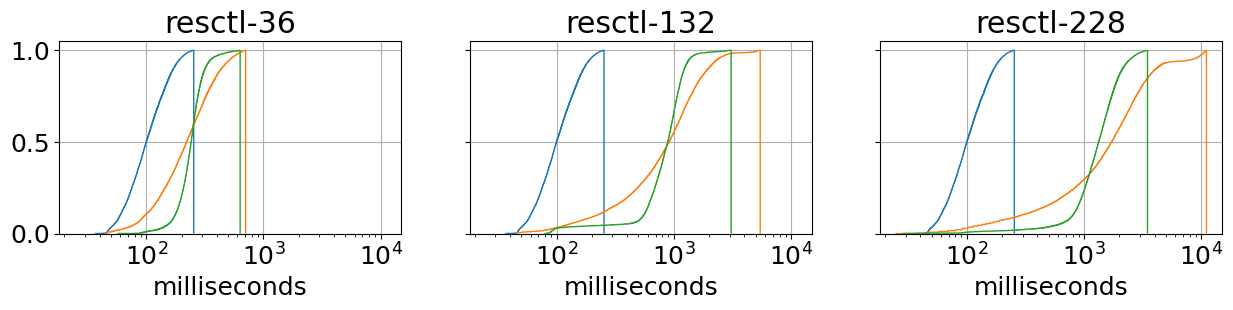

In [40]:

fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], results_notracemultithreaded_eevdf_tuned,fig,ax[0],'resctl-36',36)
visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], results_notracemultithreaded_eevdf_tuned,fig,ax[1],'resctl-132',132)
visualise_latency_cdf(pickled_data['results_notracemultithreaded_cfs'], results_notracemultithreaded_eevdf_tuned,fig,ax[2],'resctl-228',228)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,10000)

In [42]:
variables = [
    ('results_notracemultithreaded_eevdf',results_notracemultithreaded_eevdf),
    ('results_notracemultithreaded_eevdf_tuned',results_notracemultithreaded_eevdf_tuned),
]

for key,val in variables:
    print(key)
    file_dump = open(f'pickled/{key}', 'wb')
    pickle.dump(val, file_dump)

results_notracemultithreaded_eevdf
results_notracemultithreaded_eevdf_tuned


# Kernel instrumentation

In [6]:

def cat_trace_stat(backend="192.168.14.2:5000"):
    params = { 'script': 'cat_trace_stat.sh', "ema":"1000" }
    r = requests.get(f"http://{backend}/setup_patch", params=params, headers={})
    print(r.text) 
    
    return r.text
    
    
def function_profile_enabled(backend="192.168.14.2:5000",enabled=1):
    params = { "enabled":enabled }
    r = requests.get(f"http://{backend}/function_profile_enabled", params=params, headers={})
    print(r.text) 
    
    
def process_ftrace_data(ftrace_data):
    
#     print(ftrace_data.split("\n")[0].split())
#     print([x for x in range(4)])
    
    raw_schedule_lines = [line.split() for line in ftrace_data.split("\n") if re.findall("schedule",line)]
    assert(len(raw_schedule_lines) == 12)
    
    print(raw_schedule_lines)
    
    # ['schedule', '8267', '912739427', 'us', '110407.5', 'us', '224351.8', 'us']    

    schedule_hits_total = [int(line[1]) for line in raw_schedule_lines]
    schedule_time_total = [int(line[2]) for line in raw_schedule_lines]
    schedule_time_avg = [float(line[4]) for line in raw_schedule_lines]
    schedule_time_std = [float(line[6]) for line in raw_schedule_lines]
    
    schedule_time_avg_avg = sum(schedule_time_avg)/len(schedule_time_avg)
    
    return sum(schedule_hits_total), sum(schedule_time_total), schedule_time_avg_avg, max(schedule_time_std) 

In [7]:


# function_profile_enabled(enabled=0)
function_profile_enabled()
ftrace_data_raw = cat_trace_stat()
# ftrace_data = process_ftrace_data(ftrace_data_raw)
# display(ftrace_data_raw)

time.sleep(10)

ftrace_data_raw = cat_trace_stat()



Reseting ftrace state...

current_tracer, before:
     1	nop
current_tracer, after:
     1	nop

set_ftrace_filter, before:
     1	#### all functions enabled ####
set_ftrace_filter, after:
     1	#### all functions enabled ####

set_graph_function, before:
     1	#### all functions enabled ####
set_graph_function, after:
     1	#### all functions enabled ####

set_ftrace_pid, before:
     1	no pid
set_ftrace_pid, after:
     1	no pid

events/enable, before:
     1	0
events/enable, after:
     1	0

tracing_thresh, before:
     1	0
tracing_thresh, after:
     1	0

kprobe_events, before:
kprobe_events, after:

tracing_on, before:
     1	1
tracing_on, after:
     1	1

Done.
/sys/kernel/debug/tracing/function_profile_enabled
0
configurating ftrace to instrument schedule()
/sys/kernel/tracing/set_ftrace_filter
schedule
/sys/kernel/tracing/current_tracer
function
/sys/kernel/tracing/tracing_on
0
/sys/kernel/debug/tracing/function_profile_enabled
1

  Function                               Hit 

In [8]:
function_profile_enabled()

ftrace_data_raw = cat_trace_stat()


Reseting ftrace state...

current_tracer, before:
     1	function
current_tracer, after:
     1	nop

set_ftrace_filter, before:
     1	schedule
set_ftrace_filter, after:
     1	#### all functions enabled ####

set_graph_function, before:
     1	#### all functions enabled ####
set_graph_function, after:
     1	#### all functions enabled ####

set_ftrace_pid, before:
     1	no pid
set_ftrace_pid, after:
     1	no pid

events/enable, before:
     1	0
events/enable, after:
     1	0

tracing_thresh, before:
     1	0
tracing_thresh, after:
     1	0

kprobe_events, before:
kprobe_events, after:

tracing_on, before:
     1	0
tracing_on, after:
     1	1

Done.
/sys/kernel/debug/tracing/function_profile_enabled
0
configurating ftrace to instrument schedule()
/sys/kernel/tracing/set_ftrace_filter
schedule
/sys/kernel/tracing/current_tracer
function
/sys/kernel/tracing/tracing_on
0
/sys/kernel/debug/tracing/function_profile_enabled
1

  Function                               Hit    Time           

In [148]:
def call_with_retry():
    while True:
        try:
            result = schedstat_snapshot()  # Attempt to call the function
            print(f"Function succeeded: ", result)
            break  # Exit the loop if the function succeeds
        except Exception as e:
            print(f"Error occurred: {e}. Retrying...")
            time.sleep(10)  # Sleep for a short time before retrying
            
def reboot_and_wait_until_online():
    backend="192.168.14.2:5000"
    try:
        r = requests.get(f"http://{backend}/reboot", params={}, headers={})
        print(r.text) 
    except Exception as e:
        print(f"Error occurred: {e}. Waiting...")
        call_with_retry()    
    

In [145]:
call_with_retry()

Function succeeded:     idle schedule tasks_running tasks_waiting timeslices try_to_wake_up  \
0     0        0    5222439893    2119200224      10876              0   
1     0        0    2948242348     522228855       9542              0   
2     0        0    3176124302     739769982      14485              0   
3     0        0    3095665556    1203167784      18762              0   
4     0        0    2937362317    2358498107      11912              0   
5     0        0    3357264499    1395910121      12645              0   
6     0        0    2636474510    1048276583      14995              0   
7     0        0    2705863934     699065353      16284              0   
8     0        0    2252948489     313414894      13044              0   
9     0        0    2970764323    1030773694      11765              0   
10    0        0    2467422982    1268657416      12070              0   
11    0        0    2774697060     482313124      13705              0   

   try_to_wake_u

# Experiments (ftrace)

In [696]:
!ls /local/scratch/sosp25/results*

/local/scratch/sosp25/results_azure2021clean_cfs
/local/scratch/sosp25/results_azure2021clean_llf
/local/scratch/sosp25/results_azure2021ftrace_cfs
/local/scratch/sosp25/results_azure2021ftrace_llf
/local/scratch/sosp25/results_notraceclean_cfs
/local/scratch/sosp25/results_notraceclean_llf
/local/scratch/sosp25/results_notraceftrace_cfs
/local/scratch/sosp25/results_randomclean_cfs
/local/scratch/sosp25/results_randomclean_llf


In [697]:
!ls /local/scratch/results*

/local/scratch/results_azure2021ftrace_cfs
/local/scratch/results_azure2021ftrace_llf
/local/scratch/results_constantloadftrace_cfs
/local/scratch/results_constantloadftrace_llf
/local/scratch/results_dynamicloadftrace_cfs
/local/scratch/results_dynamicloadftrace_llf

/local/scratch/results:
overcommitment-90  overcommitment-95  overprovisioning


In [141]:
file_constantloadftrace_cfs = open('/local/scratch/results_constantloadftrace_cfs', 'wb')
pickle.dump(results_constantloadftrace_cfs, file_constantloadftrace_cfs)

file_constantloadftrace_llf = open('/local/scratch/results_constantloadftrace_llf', 'wb')
pickle.dump(results_constantloadftrace_llf, file_constantloadftrace_llf)   

In [142]:
file_dynamicloadftrace_cfs = open('/local/scratch/sospresults_dynamicloadftrace_cfs', 'wb')
pickle.dump(results_dynamicloadftrace_cfs, file_dynamicloadftrace_cfs)

file_dynamicloadftrace_llf = open('/local/scratch/results_dynamicloadftrace_llf', 'wb')
pickle.dump(results_dynamicloadftrace_llf, file_dynamicloadftrace_llf)   

In [97]:
import pickle


file_cfs = open('/local/scratch/sosp24results_azure2021ftrace_cfs', 'rb')
results_azure2021ftrace_cfs = pickle.load(file_cfs)

file_llf = open('/local/scratch/results_azure2021ftrace_llf', 'rb')
results_azure2021ftrace_llf = pickle.load(file_llf)

# close the file
# file.close()

In [97]:
density_range = [12]

In [111]:
density_range = [x for x in range(12, 12*15, 12)]
density_range

[12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132, 144, 156, 168]

In [137]:
density_range = [x for x in range(12, 12*20, 12*2)]
density_range

[12, 36, 60, 84, 108, 132, 156, 180, 204, 228]

In [191]:
density_range

[12,
 24,
 36,
 48,
 60,
 72,
 84,
 96,
 108,
 120,
 132,
 144,
 156,
 168,
 180,
 192,
 204,
 216,
 228]

In [ ]:
print(density_range)

results_randomftrace_cfs = {}

for x in density_range: 
    results_randomftrace_cfs[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='random',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=True)
    reboot_and_wait_until_online()
    
print(density_range)

results_randomftrace_llf = {}

for x in density_range: 
    results_randomftrace_llf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='random',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=True)
    reboot_and_wait_until_online()

In [894]:
results_notraceftrace_cfs = reorder_dict_keys(results_notraceftrace_cfs)
results_azure2021ftrace_cfs = reorder_dict_keys(results_azure2021ftrace_cfs)
results_azure2021ftrace_llf = reorder_dict_keys(results_azure2021ftrace_llf)
